Detected appliances: ['Air Conditioning', 'Computer', 'Dishwasher', 'Fridge', 'Heater', 'Lights', 'Microwave', 'Oven', 'TV', 'Washing Machine']

Training Linear Regression for: Air Conditioning
MAE  : 2.9928
RMSE : 3.7999


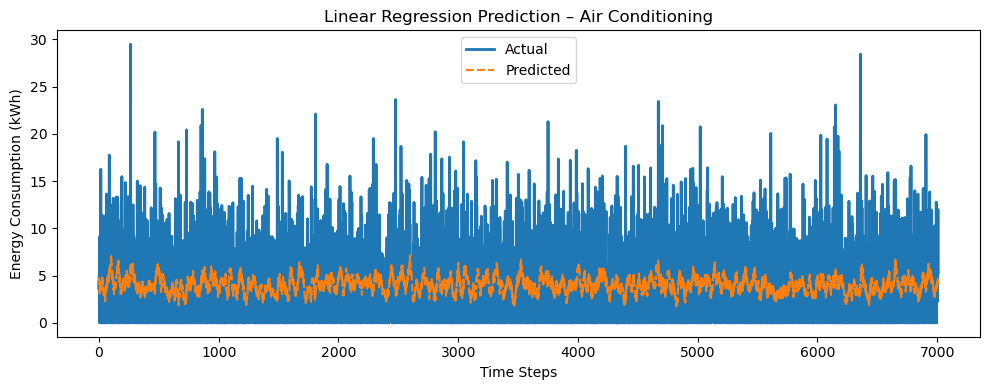


Training Linear Regression for: Computer
MAE  : 1.0077
RMSE : 1.2593


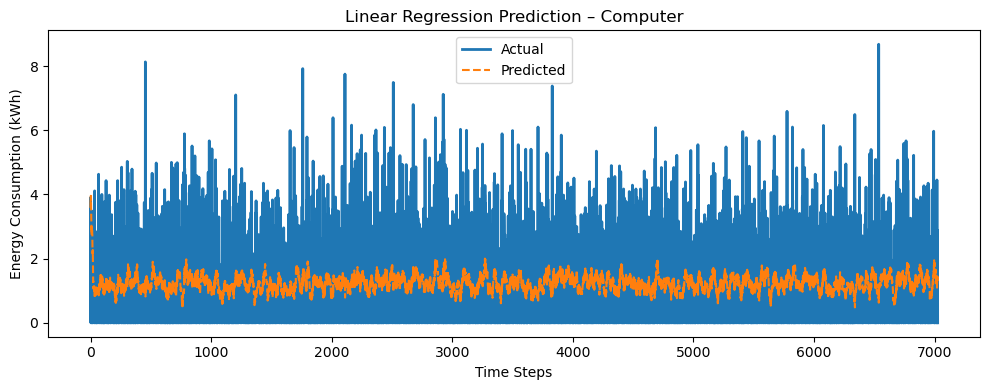


Training Linear Regression for: Dishwasher
MAE  : 1.0312
RMSE : 1.2849


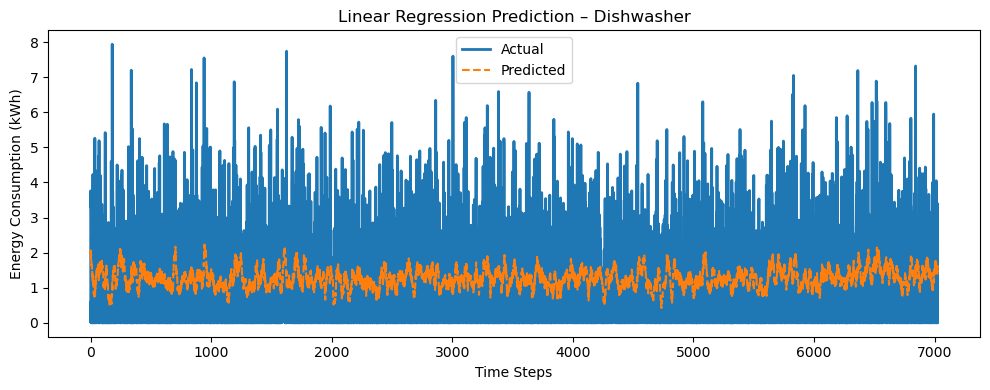


Training Linear Regression for: Fridge
MAE  : 0.2642
RMSE : 0.3326


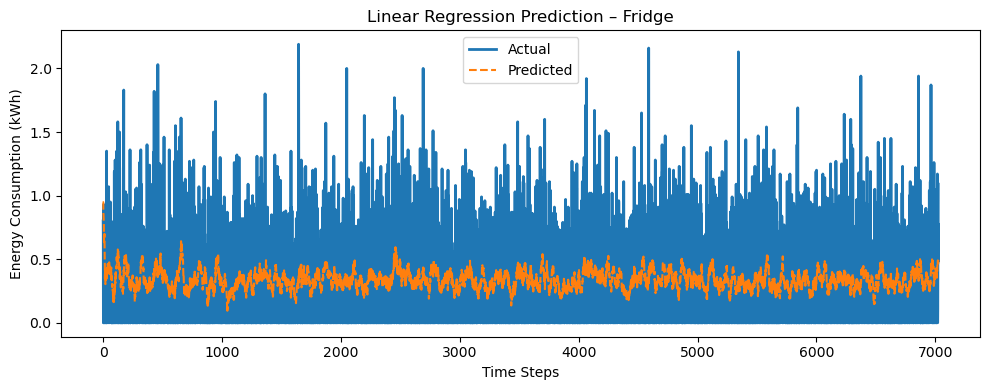


Training Linear Regression for: Heater
MAE  : 2.9867
RMSE : 3.7698


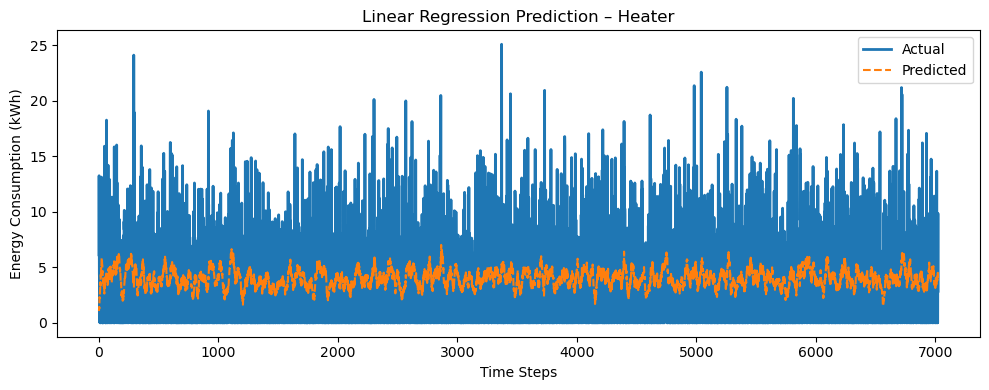


Training Linear Regression for: Lights
MAE  : 1.0207
RMSE : 1.2799


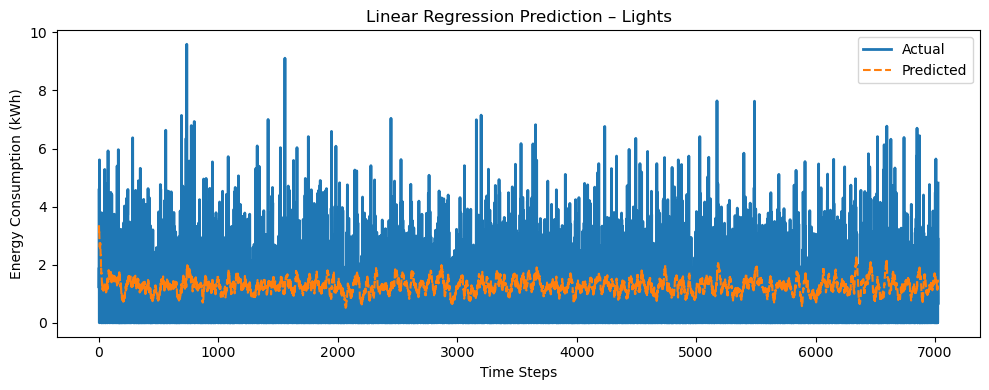


Training Linear Regression for: Microwave
MAE  : 1.0160
RMSE : 1.2655


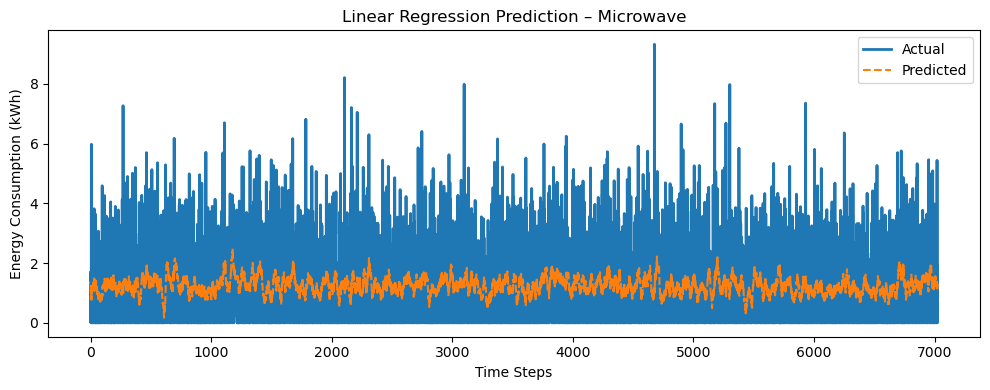


Training Linear Regression for: Oven
MAE  : 1.0325
RMSE : 1.2921


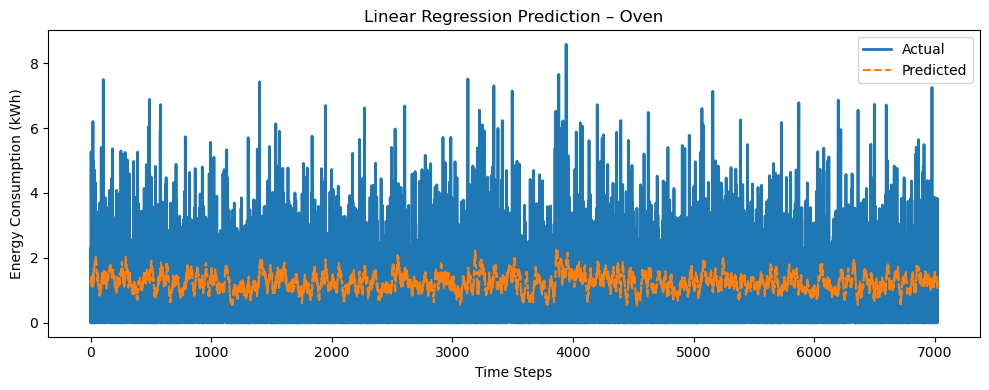


Training Linear Regression for: TV
MAE  : 1.0119
RMSE : 1.2629


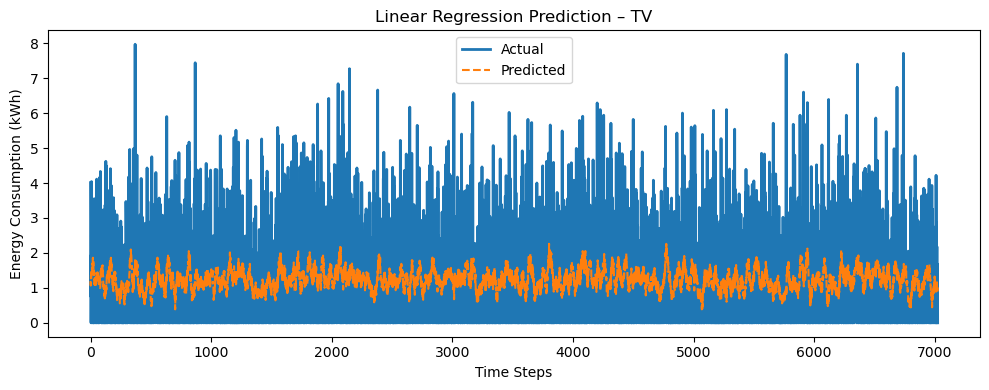


Training Linear Regression for: Washing Machine
MAE  : 1.0025
RMSE : 1.2659


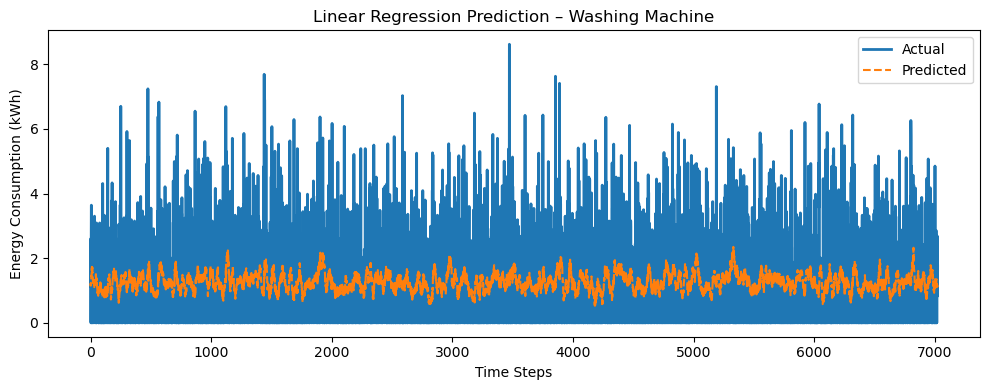


FINAL RESULTS:
          Appliance       MAE      RMSE
0  Air Conditioning  2.992844  3.799938
1          Computer  1.007688  1.259328
2        Dishwasher  1.031165  1.284860
3            Fridge  0.264250  0.332625
4            Heater  2.986724  3.769764
5            Lights  1.020736  1.279867
6         Microwave  1.015981  1.265488
7              Oven  1.032461  1.292058
8                TV  1.011910  1.262867
9   Washing Machine  1.002511  1.265921


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

data_path = r"C:\Users\mucha\OneDrive\Desktop\Infosys internship\Processed"

files = os.listdir(data_path)

# 👉 Detect appliances from filenames
appliances = sorted({
    f.replace("_x_train.csv", "")
    for f in files
    if f.endswith("_x_train.csv")
})

print("Detected appliances:", appliances)

results = []

for appliance in appliances:

    print(f"\nTraining Linear Regression for: {appliance}")

    # 👉 Load files
    x_train = pd.read_csv(f"{data_path}/{appliance}_x_train.csv")
    x_test  = pd.read_csv(f"{data_path}/{appliance}_x_test.csv")
    y_train = pd.read_csv(f"{data_path}/{appliance}_y_train.csv").values.ravel()
    y_test  = pd.read_csv(f"{data_path}/{appliance}_y_test.csv").values.ravel()

    # 👉 KEEP ONLY NUMERIC COLUMNS (important fix)
    x_train = x_train.select_dtypes(include=[np.number])
    x_test  = x_test.select_dtypes(include=[np.number])

    # 👉 Train model
    model = LinearRegression()
    model.fit(x_train, y_train)

    # 👉 Predict
    y_pred = model.predict(x_test)

    # 👉 Metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Appliance": appliance,
        "MAE": mae,
        "RMSE": rmse
    })

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")

    # 👉 Plot
    plt.figure(figsize=(10,4))
    plt.plot(y_test, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linestyle="--")
    plt.title(f"Linear Regression Prediction – {appliance}")
    plt.xlabel("Time Steps")
    plt.ylabel("Energy Consumption (kWh)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 👉 Save model
    joblib.dump(
    model,
    rf"C:\Users\mucha\OneDrive\Desktop\Infosys internship\Models_Linear_Regression\linear_regression_{appliance}.pkl"
    )


# 👉 Results table
results_df = pd.DataFrame(results)
print("\nFINAL RESULTS:")
print(results_df)
